In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/linear regression/data sets/DailyDelhiClimateTest.csv")
df = pd.DataFrame(data)

[112.09446593  -2.57154245]
mean square error: 95.25641212201262 std of y 18.984266697698267
root mean square error: 9.759939145405191
R-squared: 0.7356942771011625


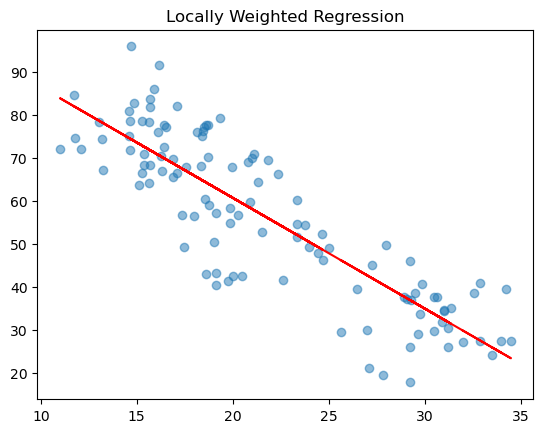

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = df['meantemp'].values
y = df['humidity'].values

x1 = x[:100]
# Add intercept term
X = np.column_stack((np.ones(len(x)), x))

# Query points (where we want predictions)
x_query = np.linspace(x.min(), x.max(), 100)


tau = 5  # bandwidth (tune this)

y_pred = []
i=0

xqr = [15,17,19]
"""
for xq in x_query:
    # Compute weights
    w = np.exp(-(x - xq)**2 / (2 * tau**2))
    W = np.diag(w)

    # Compute theta
    theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

    # Prediction
    yq = theta[0] + theta[1] * xq
    y_pred.append(yq)

print(theta)
print()
"""
   
theta2 = np.linalg.inv(X.T @ X) @ (X.T @ y)
print(theta2) 
for xq in x:


    # Prediction
    yq = theta2[0] + theta2[1] * xq
    y_pred.append(yq)

error = y-y_pred
mse = np.mean(error**2)
rmse = np.sqrt(mse)
"""
(d) Can fail if matrix is singular
Then:

np.linalg.inv fails

Solution:

Use pseudo-inverse (pinv)
"""

ymean = np.mean(y)
ss_res = np.sum(error**2)
ss_tot = np.sum((y-ymean)**2)
r2 = 1- (ss_res/ss_tot)

print(f"mean square error: {mse}", f"std of y {y.std()}")
print(f"root mean square error: {rmse}")
print(f"R-squared: {r2}")
    

# Plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color='red')
plt.title("Locally Weighted Regression")
plt.show()